## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Define Project Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = "/content/drive/MyDrive/trader-sentiment-analysis"

## 3. Load Data

In [3]:
sentiment = pd.read_csv(f"{BASE_PATH}/data/raw/fear_greed_index.csv")
trades = pd.read_csv(f"{BASE_PATH}/data/raw/historical_data.csv")

## 4. Preview Data

In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 5. Check Columns

In [6]:
print("Sentiment Columns:", sentiment.columns)
print("Trades Columns:", trades.columns)

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## 6. Check Shape

In [7]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


## 7. Check Data Types

In [8]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

# 2  DATA CLEANING

## 2.1 Clean Column Names

In [9]:
# Make column names clean and consistent
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


## 2.2 Convert Date Columns

### Sentiment Date

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

### Trades Timestamp

In [11]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

## 2.3 Create Common Date Column

In [12]:
trades['date'] = trades['timestamp_ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

## 2.4 Rename Important Columns

In [13]:
trades.rename(columns={
    'closed_pnl': 'pnl',
    'size_usd': 'trade_size',
    'account': 'account',
    'side': 'side'
}, inplace=True)

## 2.5 Handle Missing Values

In [14]:
print("Missing Values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing Values (Trades):")
print(trades.isnull().sum())

Missing Values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
account             0
coin                0
execution_price     0
size_tokens         0
trade_size          0
side                0
timestamp_ist       0
start_position      0
direction           0
pnl                 0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
dtype: int64


## 2.6 Remove Duplicates

In [15]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

## 2.7 Merge Both Datasets

In [16]:
df = pd.merge(trades, sentiment, on='date', how='left')

In [17]:
df.head()

,account,coin,execution_price,size_tokens,trade_size,side,timestamp_ist,start_position,direction,pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [18]:
df.shape

(211224, 20)

In [19]:
df['classification'].isnull().sum()

np.int64(6)

## 2.8 Remove Missing Sentiment Rows

In [20]:
df = df.dropna(subset=['classification'])

## 2.9 Drop Unnecessary Columns

In [21]:
df = df.drop(columns=['timestamp_x', 'timestamp_y'])

In [22]:
df.shape

(211218, 18)

In [23]:
df.head()

,account,coin,execution_price,size_tokens,trade_size,side,timestamp_ist,start_position,direction,pnl,transaction_hash,order_id,crossed,fee,trade_id,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02,80.0,Extreme Greed


# 3. FEATURE ENGINEERING

## 3.1 Win / Loss

In [24]:
df['win'] = df['pnl'] > 0

## 3.2 Daily PnL per Trader

In [25]:
daily_pnl = df.groupby(['account', 'date'])['pnl'].sum().reset_index()

## 3.3 Win Rate

In [26]:
win_rate = df.groupby('account')['win'].mean().reset_index()

## 3.4 Trades per Day

In [27]:
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

## 3.5 Long / Short Ratio

In [28]:
long_short = df['side'].value_counts(normalize=True)
print(long_short)

side
SELL    0.51382
BUY     0.48618
Name: proportion, dtype: float64


## 3.6 Average Trade Size

In [29]:
avg_trade_size = df.groupby('account')['trade_size'].mean().reset_index()

## 3.7 Leverage

In [30]:
df['leverage_proxy'] = df['trade_size'] / df['execution_price']

In [31]:
daily_pnl.head()

,account,date,pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [32]:
win_rate.head()

,account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [33]:
trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


# 4. How does Fear vs Greed affect trading?

## 4.1 Performance vs Sentiment

### PnL Comparison

In [34]:
df.groupby('classification')['pnl'].mean()

,pnl
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


### Win Rate Comparison

In [35]:
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


### Visualization

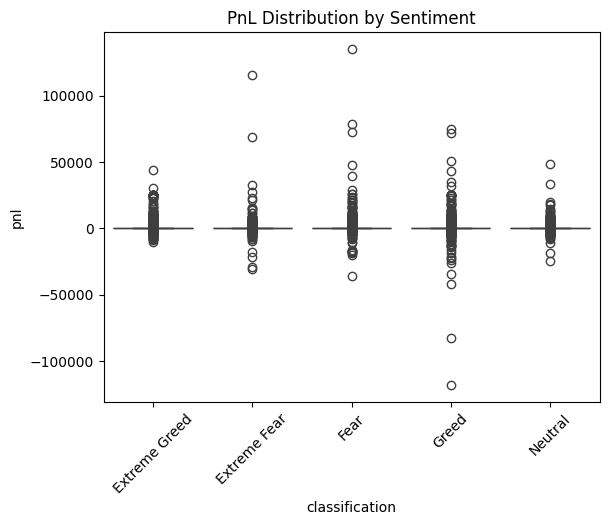

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

## 4.2 Behavior vs Sentiment

### Trade Frequency

In [37]:
df.groupby('classification').size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


### Average Trade Size

In [38]:
df.groupby('classification')['trade_size'].mean()

,trade_size
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


### Long / Short Bias

In [39]:
pd.crosstab(df['classification'], df['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


## 4.3 SEGMENT ANALYSIS

### 4.3.1 High vs Low Trade Size

In [40]:
df['size_group'] = df['trade_size'].apply(lambda x: 'High' if x > df['trade_size'].median() else 'Low')

In [41]:
df.groupby(['size_group', 'classification'])['pnl'].mean()

size_group  classification
High        Extreme Fear       61.196379
            Extreme Greed     140.570044
            Fear               97.025581
            Greed              84.301244
            Neutral            69.581271
Low         Extreme Fear        1.157202
            Extreme Greed       9.628661
            Fear                3.580906
            Greed               3.609685
            Neutral             2.188668
Name: pnl, dtype: float64

### 4.3.2 Frequent Traders

In [42]:
trade_counts = df['account'].value_counts()

frequent = trade_counts[trade_counts > 50].index

df['trader_type'] = df['account'].apply(lambda x: 'Frequent' if x in frequent else 'Infrequent')

In [43]:
df.groupby(['trader_type', 'classification'])['pnl'].mean()

trader_type  classification
Frequent     Extreme Fear      34.537862
             Extreme Greed     67.892861
             Fear              54.290400
             Greed             42.743559
             Neutral           34.307718
Name: pnl, dtype: float64

### 4.3.3 Winners vs Losers

In [44]:
profit = df.groupby('account')['pnl'].sum()

winners = profit[profit > 0].index

df['performance'] = df['account'].apply(lambda x: 'Winner' if x in winners else 'Loser')

In [45]:
df.groupby(['performance', 'classification'])['pnl'].mean()

performance  classification
Loser        Extreme Fear      -22.598398
             Extreme Greed      51.702381
             Fear               46.768567
             Greed            -202.027754
             Neutral            17.327765
Winner       Extreme Fear       37.989084
             Extreme Greed      68.000450
             Fear               54.792435
             Greed              54.444738
             Neutral            35.049780
Name: pnl, dtype: float64

# Trader Performance vs Market Sentiment Analysis

## Key Insights

### 1. Trade Size Strongly Impacts Profitability
Analysis shows that **high-size trades generate significantly higher PnL** compared to low-size trades across all sentiment conditions.  
For example, during *Extreme Greed*, high-size trades yield ~140 PnL vs ~9 for low-size trades (~10x difference).

This indicates that **position sizing is a major driver of profitability**, especially in strong market conditions.

Additionally, traders tend to increase trade sizes during Greed and Extreme Greed periods, reinforcing the link between market sentiment and risk-taking behavior.

**Observation:**  
Average trade size increases during Greed and Extreme Greed periods, indicating higher risk-taking behavior by traders in bullish markets.

---

### 2. Greed Amplifies Both Profit and Loss
During *Greed* phases, trader performance becomes highly polarized:
- Winning traders achieve strong positive returns  
- Losing traders incur **very large losses (up to -202 PnL)**  

This suggests that **Greed increases market volatility and risk exposure**, benefiting skilled traders but penalizing weaker ones.

---

### 3. Frequent Trading Does Not Guarantee Higher Returns
Frequent traders do not consistently outperform infrequent traders.  
Despite higher activity, their average profitability remains moderate.

This indicates that **overtrading reduces efficiency and may lead to unnecessary losses**, especially in volatile sentiment phases.

---

### 4. Extreme Greed Offers Highest Profit Potential
Across all segments, *Extreme Greed* periods show the **highest average profitability**.

This is likely due to **strong directional momentum**, where markets trend clearly, allowing traders to capitalize more effectively.

---

## Strategy Recommendations

### 1. Position Sizing Strategy
Low-size trades generated ~10x lower returns than high-size trades, particularly during Extreme Greed conditions.

**Recommendation:**  
Traders should **increase position sizes selectively during strong bullish sentiment (Extreme Greed)** to maximize returns, while maintaining proper risk controls.

---

### 2. Risk Management Strategy
During Greed conditions, underperforming traders experienced losses as large as -202 PnL.

**Recommendation:**  
Traders with inconsistent performance should **reduce leverage and avoid aggressive positions during Greed phases**, as market conditions amplify downside risk.

---

### 3. Trade Frequency Optimization
Frequent traders do not show significantly higher profitability despite increased activity.

**Recommendation:**  
Traders should **avoid overtrading and focus on high-quality, high-confidence trades**, especially during volatile sentiment periods.

---

## Methodology

- Cleaned and merged trader and sentiment datasets on a daily level  
- Converted timestamps and aligned datasets  
- Engineered key metrics:
  - Profit & Loss (PnL)
  - Win rate
  - Trade frequency
  - Trade size  
- Segmented traders into:
  - High vs Low trade size  
  - Frequent vs Infrequent traders  
  - Winners vs Losers  
- Performed comparative analysis across sentiment regimes  

---

## Conclusion

This analysis demonstrates that **market sentiment significantly influences both trader behavior and performance**.  
While bullish conditions (Extreme Greed) offer higher profit potential, they also introduce higher risk, emphasizing the importance of **position sizing, risk control, and disciplined trading strategies**.

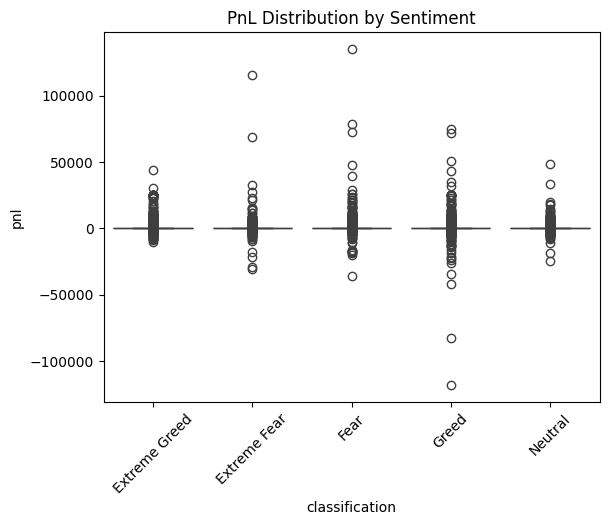

In [46]:
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x='classification', y='pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)

plt.savefig(f"{BASE_PATH}/outputs/charts/pnl_vs_sentiment.png")
plt.show()

In [47]:
df.to_csv(f"{BASE_PATH}/data/processed/merged_data.csv", index=False)

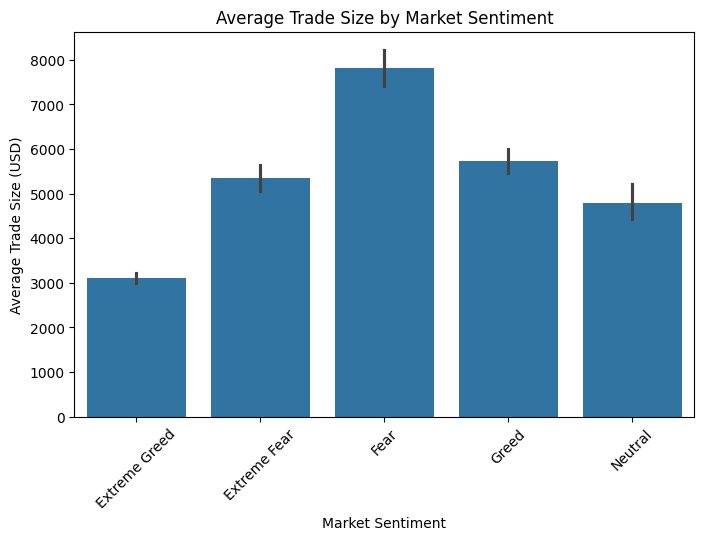

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x='classification', y='trade_size', data=df)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)

# Save chart
plt.savefig(f"{BASE_PATH}/outputs/charts/trade_size_vs_sentiment.png")

plt.show()

### Summary Table: Performance by Market Sentiment

The table below shows average profitability and win rate across different sentiment conditions. Higher values during Extreme Greed indicate stronger market momentum.

### 1. Round + Rename Columns

In [49]:
summary_pnl = df.groupby('classification')['pnl'].mean().reset_index()

summary_pnl.columns = ['Sentiment', 'Average PnL']
summary_pnl['Average PnL'] = summary_pnl['Average PnL'].round(2)

summary_pnl

,Sentiment,Average PnL
0,Extreme Fear,34.54
1,Extreme Greed,67.89
2,Fear,54.29
3,Greed,42.74
4,Neutral,34.31


### 2. Win Rate Table

In [50]:
summary_win = df.groupby('classification')['win'].mean().reset_index()

summary_win.columns = ['Sentiment', 'Win Rate']
summary_win['Win Rate'] = (summary_win['Win Rate'] * 100).round(2)

summary_win

,Sentiment,Win Rate
0,Extreme Fear,37.06
1,Extreme Greed,46.49
2,Fear,42.08
3,Greed,38.48
4,Neutral,39.70


In [51]:
summary_pnl.style.background_gradient(cmap='Blues')

,Sentiment,Average PnL
0,Extreme Fear,34.540000
1,Extreme Greed,67.890000
2,Fear,54.290000
3,Greed,42.740000
4,Neutral,34.310000


In [52]:
summary_win.style.background_gradient(cmap='Greens')

,Sentiment,Win Rate
0,Extreme Fear,37.060000
1,Extreme Greed,46.490000
2,Fear,42.080000
3,Greed,38.480000
4,Neutral,39.700000


## SAVE TABLE

In [56]:
summary_pnl.to_csv(f"{BASE_PATH}/outputs/tables/summary_pnl.csv", index=False)
summary_win.to_csv(f"{BASE_PATH}/outputs/tables/summary_win.csv", index=False)


# 1. CLUSTERING

## 1.1 Create Trader Features

In [57]:
trader_features = df.groupby('account').agg({
    'pnl': 'mean',
    'trade_size': 'mean',
    'win': 'mean'
}).reset_index()

trader_features.head()

,account,pnl,trade_size,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914


## 1.2 Apply K-Means Clustering

In [58]:
from sklearn.cluster import KMeans

X = trader_features[['pnl', 'trade_size', 'win']]

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

## 1.3 See Cluster Summary

In [59]:
trader_features.dtypes

,0
account,object
pnl,float64
trade_size,float64
win,float64
cluster,int32


In [60]:
trader_features.groupby('cluster')[['pnl', 'trade_size', 'win']].mean()

,pnl,trade_size,win
cluster,,,
0,141.606524,10662.058105,0.357665
1,88.380205,2637.605204,0.415288
2,36.666362,28450.568057,0.419902


## 1.4 Visualize Clusters

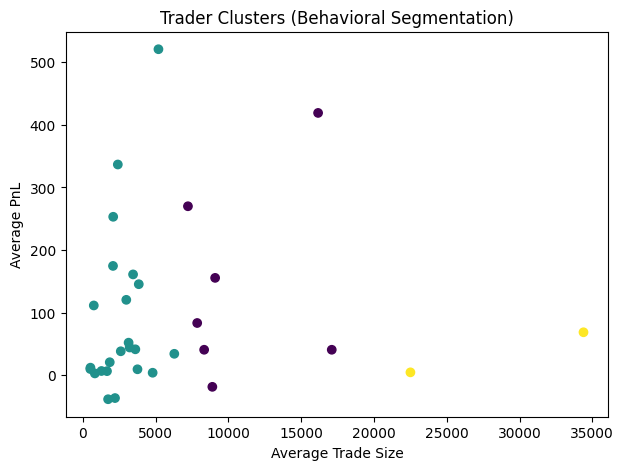

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    trader_features['trade_size'],
    trader_features['pnl'],
    c=trader_features['cluster']
)

plt.xlabel("Average Trade Size")
plt.ylabel("Average PnL")
plt.title("Trader Clusters (Behavioral Segmentation)")

plt.show()

## Trader Clustering (Behavioral Segmentation)

Traders were grouped into 3 clusters based on profitability, trade size, and win rate.

- Cluster 0 : High profitability with larger trade sizes but lower win rates -> Risk-tolerant traders relying on large gains  
- Cluster 1 : Moderate profitability with smaller trade sizes and higher consistency -> Balanced traders  
- Cluster 2 : Very large trade sizes with relatively low profitability -> High-risk but inefficient traders  

This segmentation highlights that simply increasing trade size does not guarantee higher returns, and efficient risk management is critical for sustained profitability.

# 2. PREDICTIVE MODEL

## 2.1 Prepare Data

In [62]:
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes

df['profit_label'] = (df['pnl'] > 0).astype(int)

features = ['trade_size', 'execution_price', 'sentiment_encoded']

X = df[features]
y = df['profit_label']

## 2.2 Train/Test Split

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 2.3 Train Model

In [64]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## 2.4 Evaluate Model

In [65]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8211106902755421


## 2.5 Feature Importance

In [66]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

execution_price      0.601363
trade_size           0.385705
sentiment_encoded    0.012932
dtype: float64


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85     24848
           1       0.80      0.75      0.78     17396

    accuracy                           0.82     42244
   macro avg       0.82      0.81      0.81     42244
weighted avg       0.82      0.82      0.82     42244



## 2.6 CONFUSION MATRIX

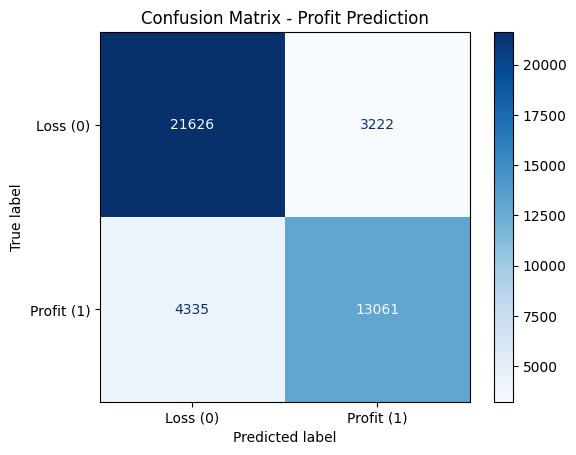

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Loss (0)", "Profit (1)"]
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Profit Prediction")
plt.show()

## Predictive Modeling

A Random Forest classifier was trained to predict trade profitability using trade size, execution price, and market sentiment

The model achieved an accuracy of approximately 82%, indicating strong predictive capability.

Feature importance analysis revealed that:
- Execution price is the most significant factor (~ 60%)
- Trade size also plays a major role (~ 38%)
- Market sentiment has minimal direct impact (~ 1%)

This suggests that **trader behavior and execution decisions have a much stronger influence on profitability than market sentiment alone**.

### Model Evaluation

The model achieved an accuracy of ~82%, with balanced performance across classes.

- It performs better at identifying loss-making trades (recall ~87%)
- Profit prediction is slightly lower (recall ~75%), indicating some profitable trades are missed

This suggests that the model is more conservative and better at avoiding losses, which is desirable in trading scenarios where risk management is critical.